# LIBRERÍAS Y CONFIGURACIÓN

In [ ]:
# Importación de librerías necesarias según el Ciclo 1 (Scikit-learn)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score, precision_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías importadas correctamente.")

✅ Librerías importadas correctamente.


# CARGA DEL DATASET

In [ ]:
# ============================================================================
# CARGA MANUAL DEL ARCHIVO EXCEL
# ============================================================================
print("📁 SUBIR ARCHIVO EXCEL")
print("="*60)
print("Hacé clic en 'Choose Files' y seleccioná tu archivo Excel")
print("="*60)

# Subir archivo
uploaded = files.upload()

# Verificar que se haya subido un archivo
if uploaded:
    archivo_nombre = list(uploaded.keys())[0]
    print(f"\n✅ Archivo cargado: {archivo_nombre}")

    # Cargar el dataset
    df = pd.read_excel(archivo_nombre, sheet_name='Hoja1')

    # Limpieza de datos
    df = df.dropna(subset=['PedidosHechos'])
    df = df.reset_index(drop=True)

    # Eliminar columna Fecha si existe
    if 'Fecha' in df.columns:
        df.drop(columns=['Fecha'], inplace=True)

    print(f"\n📊 Dataset cargado exitosamente:")
    print(f"   - Registros: {df.shape[0]}")
    print(f"   - Columnas: {df.shape[1]}")
    print(f"\n📋 Primeras filas:")
    df.head(10)

else:
    print("❌ No se subió ningún archivo. Por favor, ejecutá la celda nuevamente.")

📁 SUBIR ARCHIVO EXCEL
Hacé clic en 'Choose Files' y seleccioná tu archivo Excel


Saving DATASET TIF.xlsx to DATASET TIF.xlsx

✅ Archivo cargado: DATASET TIF.xlsx

📊 Dataset cargado exitosamente:
   - Registros: 4354
   - Columnas: 4

📋 Primeras filas:


🎯 VARIABLE OBJETIVO (Target) - Binario
Criterio: PedidosHechos < 2 → DEMANDA NORMAL (0)
Criterio: PedidosHechos >= 2 → ALTA DEMANDA (1)

📈 Distribución de clases (Binario):
AltaDemanda
0    2195
1    2159
Name: count, dtype: int64

Proporción (Binario):
  - Demanda Normal (0): 2195 registros (50.4%)
  - Alta Demanda (1): 2159 registros (49.6%)


🎯 NIVELES DE DEMANDA (Para Visualización)
Criterio: PedidosHechos = 0 → BAJA DEMANDA
Criterio: PedidosHechos = 1 → DEMANDA NORMAL
Criterio: PedidosHechos >= 2 → ALTA DEMANDA

📈 Distribución de niveles de demanda (Categórico):
NivelDemandaCategorico
Alta Demanda      2159
Demanda Normal    1105
Baja Demanda      1090
Name: count, dtype: int64

Proporción (Categórico):
  - Baja Demanda: 1090 registros (25.0%)
  - Demanda Normal: 1105 registros (25.4%)
  - Alta Demanda: 2159 registros (49.6%)


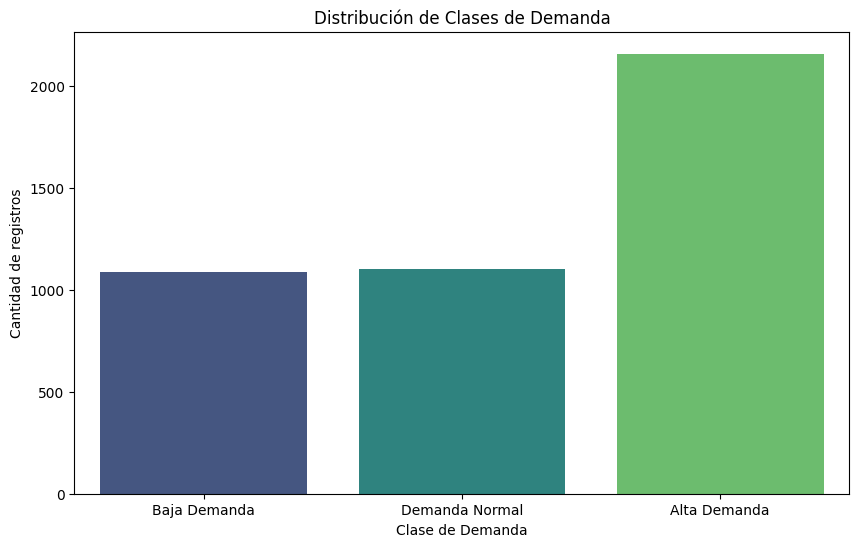

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# DEFINICIÓN DEL TARGET (Alta Demanda y Nivel de Demanda Categórico)
# ============================================================================
# Según el problema del Word:
# Clasificar en "Alta Demanda" vs "Demanda Normal" (binary target)
# Además, visualizar "Baja Demanda" para PedidosHechos = 0

# Binary Target (AltaDemanda):
df['AltaDemanda'] = (df['PedidosHechos'] >= 2).astype(int)

# Categorical variable for visualization (NivelDemandaCategorico):
def categorizar_nivel_demanda(pedidos):
    if pedidos == 0:
        return 'Baja Demanda'
    elif pedidos == 1:
        return 'Demanda Normal'
    else: # pedidos >= 2
        return 'Alta Demanda'

df['NivelDemandaCategorico'] = df['PedidosHechos'].apply(categorizar_nivel_demanda)

print("🎯 VARIABLE OBJETIVO (Target) - Binario")
print("="*60)
print("Criterio: PedidosHechos < 2 → DEMANDA NORMAL (0)")
print("Criterio: PedidosHechos >= 2 → ALTA DEMANDA (1)")
print("="*60)
print("\n📈 Distribución de clases (Binario):")
print(df['AltaDemanda'].value_counts())
print(f"\nProporción (Binario):")
print(f"  - Demanda Normal (0): {(df['AltaDemanda']==0).sum()} registros ({(df['AltaDemanda']==0).mean()*100:.1f}%)")
print(f"  - Alta Demanda (1): {(df['AltaDemanda']==1).sum()} registros ({(df['AltaDemanda']==1).mean()*100:.1f}%)")

print("\n\n🎯 NIVELES DE DEMANDA (Para Visualización)")
print("="*60)
print("Criterio: PedidosHechos = 0 → BAJA DEMANDA")
print("Criterio: PedidosHechos = 1 → DEMANDA NORMAL")
print("Criterio: PedidosHechos >= 2 → ALTA DEMANDA")
print("="*60)
print("\n📈 Distribución de niveles de demanda (Categórico):")
print(df['NivelDemandaCategorico'].value_counts())
print(f"\nProporción (Categórico):")
baja_demanda_count = (df['NivelDemandaCategorico'] == 'Baja Demanda').sum()
normal_demanda_categorico_count = (df['NivelDemandaCategorico'] == 'Demanda Normal').sum()
alta_demanda_categorico_count = (df['NivelDemandaCategorico'] == 'Alta Demanda').sum()
total_records = df.shape[0]

print(f"  - Baja Demanda: {baja_demanda_count} registros ({baja_demanda_count/total_records*100:.1f}%)")
print(f"  - Demanda Normal: {normal_demanda_categorico_count} registros ({normal_demanda_categorico_count/total_records*100:.1f}%)")
print(f"  - Alta Demanda: {alta_demanda_categorico_count} registros ({alta_demanda_categorico_count/total_records*100:.1f}%)")

# Visualización
plt.figure(figsize=(10, 6)) # Increased figure size for better readability
sns.countplot(data=df, x='NivelDemandaCategorico', palette='viridis',
              order=['Baja Demanda', 'Demanda Normal', 'Alta Demanda']) # Specify order for consistent plotting
plt.title('Distribución de Clases de Demanda')
plt.ylabel('Cantidad de registros')
plt.xlabel('Clase de Demanda')
plt.show()

In [ ]:
def clasificar_demanda(pedidos):
    if pedidos == 0:
        return "Baja"
    elif pedidos == 1:
        return "Normal"
    else:
        return "Alta"

df["NivelDemanda"] = df["PedidosHechos"].apply(clasificar_demanda)

X = df[["Mes","Día","HorarioXhora"]]
y = df["NivelDemanda"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

modelo = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

modelo.fit(X_train, y_train)

print(y.unique())
print(y.dtype)

['Baja' 'Alta' 'Normal']
object


In [ ]:
df["NivelDemanda"].value_counts()

,count
NivelDemanda,
Alta,2159
Normal,1105
Baja,1090


In [ ]:
X = df[["Mes","Día","HorarioXhora"]]
y = df["NivelDemanda"]

Entrenamos el modelo

In [ ]:
X = df[["Mes", "Día", "HorarioXhora"]]
y = df["NivelDemanda"]

In [ ]:
print(modelo.classes_)

['Alta' 'Baja' 'Normal']


In [ ]:
#EVALUAMOS EL MODELO

from sklearn.metrics import classification_report

pred = modelo.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

        Alta       0.49      0.56      0.52       432
        Baja       0.25      0.22      0.23       218
      Normal       0.26      0.22      0.23       221

    accuracy                           0.39       871
   macro avg       0.33      0.33      0.33       871
weighted avg       0.37      0.39      0.38       871



Predicción Interactiva

In [ ]:
mes = int(input("Mes: "))
dia = int(input("Día: "))
hora = int(input("Hora: "))

nuevo = pd.DataFrame({
    "Mes":[mes],
    "Día":[dia],
    "HorarioXhora":[hora]
})

prediccion = modelo.predict(nuevo)[0]

print("Nivel de demanda esperado:", prediccion)


probabilidades = modelo.predict_proba(nuevo)[0]

for clase, prob in zip(modelo.classes_, probabilidades):
    print(f"{clase}: {prob*100:.2f}%")


if prediccion == "Alta":
    print("🟢 Se recomienda trabajar en este horario.")
elif prediccion == "Normal":
    print("🟡 Existe una demanda moderada.")
else:
    print("🔴 No se recomienda trabajar en este horario.")



Mes: 6
Día: 5
Hora: 20
Nivel de demanda esperado: Baja
Alta: 33.40%
Baja: 33.57%
Normal: 33.02%
🔴 No se recomienda trabajar en este horario.


In [7]:
### CARGA DEL DATASET


from google.colab import files

uploaded = files.upload()


Saving DATASET TIF.xlsx to DATASET TIF.xlsx


In [19]:
### INSTALACIÓN DE LIBRERÍAS
!pip install streamlit joblib openpyxl -q

In [20]:
### ENTRENAR Y GUARDAR MODELO

import pandas as pd
import joblib
from sklearn.ensemble import RandomForestClassifier


# CARGAR DATASET
df = pd.read_excel("DATASET TIF.xlsx")


# VER COLUMNAS
print(df.columns)


# VARIABLES
X = df[['Mes', 'Día', 'HorarioXhora']]
y = df['PedidosHechos']


# ENTRENAR MODELO
modelo = RandomForestClassifier()
modelo.fit(X, y)


# GUARDAR MODELO
joblib.dump(modelo, "modelo.pkl")
print("Modelo guardado correctamente")

Index(['Mes', 'Fecha', 'Día', 'HorarioXhora', 'PedidosHechos'], dtype='object')
Modelo guardado correctamente


In [34]:
### CREACIÓN DE LA APP.PY

%%writefile app.py

import streamlit as st
import joblib
import pandas as pd


# CARGAR MODELO
modelo = joblib.load("modelo.pkl")

# INTERFAZ
st.title("Predicción de Pedidos")

st.write("Ingrese los datos para realizar la predicción.")

# INPUTS
mes = st.number_input(
    "Mes",
    min_value=1,
    max_value=12
)

dia = st.number_input(
    "Día",
    min_value=1,
    max_value=31
)

hora = st.number_input(
    "Horario por Hora",
    min_value=0,
    max_value=23
)


# PREDICCIÓN
if st.button("Predecir"):

    datos = pd.DataFrame({
        'Mes': [mes],
        'Día': [dia],
        'HorarioXhora': [hora]
    })

    prediccion = modelo.predict(datos)

    st.success(
        f"Pedidos estimados: {prediccion[0]}"
    )

Overwriting app.py


In [35]:
###EJECUCIÓN DEL STREAMLIT
!streamlit run app.py



2026-06-12 18:31:59.081 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.60.224.64:8501

  Stopping...


CREACIÓN DEL README

In [29]:
%%writefile README.md

# Predicción de Pedidos con Streamlit

## Descripción
Este proyecto utiliza Machine Learning para predecir la cantidad de pedidos realizados en función del mes, día y horario.

La aplicación fue desarrollada con Streamlit y el modelo fue entrenado con RandomForestClassifier.

---

## Tecnologías utilizadas

- Python
- Pandas
- Scikit-learn
- Streamlit
- Joblib

---

## Archivos del proyecto

- `Avance_3_TIF.ipynb` → Notebook principal
- `app.py` → Aplicación Streamlit
- `modelo.pkl` → Modelo entrenado
- `DATASET TIF.xlsx` → Dataset utilizado

---

## Instalación

Instalar las librerías necesarias:

```bash
pip install streamlit pandas scikit-learn joblib openpyxl


Overwriting README.md


In [30]:
#DESCARGA DE README
from google.colab import files

files.download("README.md")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
!streamlit run app.py



2026-06-12 18:03:33.944 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.60.224.64:8501

  Stopping...


In [26]:
###DESCARGA DEL MODELO PKL

from google.colab import files

files.download("modelo.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>